## Importing Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Loading Dataset and Data Preprocessing

In [2]:
# Load dataset
df = pd.read_csv("Iris.csv")  # or provide path if needed

# Drop unnecessary columns (like Id)
df.drop("Id", axis=1, inplace=True)

# Encode target variable 'Species'
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Features and target
X = df.drop("Species", axis=1)
y = df["Species"]

## Split the Dataset

In [3]:

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

In [4]:
# Initialize models
lr = LogisticRegression(max_iter=200)
rf = RandomForestClassifier(random_state=42)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predict
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)

## Model Evaluation

In [5]:

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

print("\nClassification Report (Random Forest):\n", classification_report(y_test, rf_preds, target_names=le.classes_))

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0

Classification Report (Random Forest):
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## Confusion Matrix

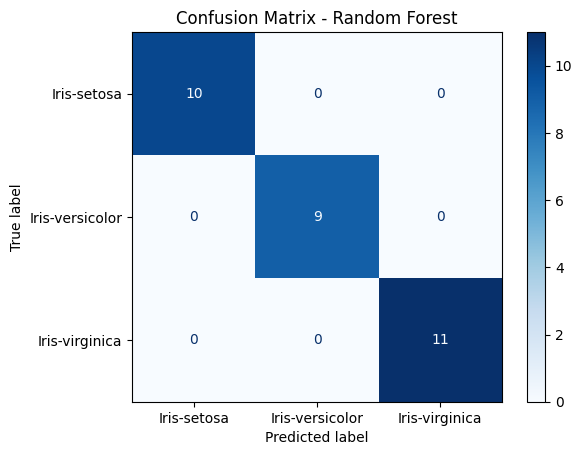

In [6]:
cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()